# Análisis exploratorio de datos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("content/train.csv")


In [18]:
print("No. of rows: ", df.shape[0])
print("No. of columns: ", df.shape[1])

No. of rows:  1458644
No. of columns:  11


In [19]:
# Dividir en entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


In [20]:
print("No. de filas en el conjunto de entrenamiento:", train_df.shape[0])
print("No. de columnas en el conjunto de entrenamiento:", train_df.shape[1])


No. de filas en el conjunto de entrenamiento: 1166915
No. de columnas en el conjunto de entrenamiento: 11


In [24]:
train_df = train_df.reset_index(drop=True)
#Mantener secuencia en los indices

In [25]:
train_df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id0458976,2,2016-06-29 18:21:02,2016-06-29 18:39:55,1,-73.862762,40.768822,-73.891701,40.746689,N,1133
1,id0434613,2,2016-04-25 13:03:26,2016-04-25 13:18:13,1,-73.958038,40.783237,-73.975510,40.760853,N,887
2,id3809234,2,2016-05-07 12:36:09,2016-05-07 12:47:35,1,-73.969460,40.785519,-73.989243,40.771748,N,686
3,id1203705,1,2016-05-14 18:44:17,2016-05-14 18:57:55,1,-73.981743,40.736549,-73.998352,40.726440,N,818
4,id1896645,2,2016-04-10 22:51:25,2016-04-10 23:07:16,1,-73.977913,40.752609,-73.975647,40.733139,N,951


In [26]:
train_df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


Revisaremos las variables pickup_datetime y dropoff_datetime debido a que son de tipo object en lugar de datetime64.

In [30]:
# Missing values
print(train_df.isnull().sum())


id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [32]:
train_df.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,object
dropoff_datetime,object
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object


En el paso anterior verificamos el clase de variables y podemos ver que tenemos de todo tipo, seguido de esto estaremos haciendo unas modificaciones en los tipos de variables para un mejor manejo de los datos.

In [36]:
# Transformando las columnas de fecha y hora (pickup y dropoff) en objetos de tipo datetime
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
train_df['dropoff_datetime'] = pd.to_datetime(train_df['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')

In [37]:
# Transformando vendor_id y store_and_fwd_flag a tipo de dato categórico
train_df['vendor_id'] = train_df['vendor_id'].astype('category')
train_df['store_and_fwd_flag'] = train_df['store_and_fwd_flag'].astype('category')

In [38]:
# Convirtiendo la variable de "Sí/No" a 1 y 0 y transformándola en tipo de dato categórico
train_df['store_and_fwd_flag'] = 1 * (train_df.store_and_fwd_flag.values == 'Y')
train_df['store_and_fwd_flag'] = train_df['store_and_fwd_flag'].astype('category')

In [40]:
# Muestra las primeras 10 filas
print(train_df.tail())

                id vendor_id     pickup_datetime    dropoff_datetime  \
1166910  id1753868         2 2016-03-25 07:11:49 2016-03-25 07:33:10   
1166911  id2204747         1 2016-02-16 18:01:45 2016-02-16 18:15:38   
1166912  id3043606         2 2016-01-26 19:22:29 2016-01-26 19:43:54   
1166913  id1458584         1 2016-01-19 11:53:47 2016-01-19 12:00:16   
1166914  id0357025         2 2016-02-10 22:39:31 2016-02-10 23:05:41   

         passenger_count  pickup_longitude  pickup_latitude  \
1166910                2        -73.955032        40.777328   
1166911                1        -73.973618        40.763920   
1166912                1        -74.006195        40.734283   
1166913                1        -73.962341        40.767323   
1166914                1        -73.874649        40.774071   

         dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  
1166910         -74.006203         40.749424                  0           1281  
1166911         -73.983849

In [41]:
# Calcula la duración del viaje en segundos usando las columnas de fecha y hora
train_df['check_trip_duration'] = (train_df['dropoff_datetime'] - train_df['pickup_datetime']).map(lambda x: x.total_seconds())

# Encuentra viajes donde la duración calculada difiere de la duración reportada en más de 1 segundo
duration_difference = train_df[np.abs(train_df['check_trip_duration'].values - train_df['trip_duration'].values) > 1]

# Muestra la forma (filas, columnas) del DataFrame con las diferencias
duration_difference.shape


(0, 12)

In [42]:
print("Startdate: ", train_df['pickup_datetime'].min())
print("Enddate: ", train_df['pickup_datetime'].max())


Startdate:  2016-01-01 00:00:17
Enddate:  2016-06-30 23:59:39


Tenemos datos en un rango de los primeros seis meses del año 2016.

In [43]:
# Creando nuevas características a partir de las columnas de fecha y hora

# Para la fecha y hora de recogida (pickup)
train_df['dia_recogida'] = train_df['pickup_datetime'].dt.day          # Día del mes
train_df['hora_recogida'] = train_df['pickup_datetime'].dt.hour        # Hora del día
train_df['dia_semana_recogida'] = train_df['pickup_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)

# Para la fecha y hora de llegada (dropoff)
train_df['dia_llegada'] = train_df['dropoff_datetime'].dt.day          # Día del mes
train_df['hora_llegada'] = train_df['dropoff_datetime'].dt.hour        # Hora del día
train_df['dia_semana_llegada'] = train_df['dropoff_datetime'].dt.weekday  # Día de la semana (0: Lunes, 6: Domingo)


In [45]:
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,check_trip_duration,dia_recogida,hora_recogida,dia_semana_recogida,dia_llegada,hora_llegada,dia_semana_llegada
0,id0458976,2,2016-06-29 18:21:02,2016-06-29 18:39:55,1,-73.862762,40.768822,-73.891701,40.746689,0,1133,1133.0,29,18,2,29,18,2
1,id0434613,2,2016-04-25 13:03:26,2016-04-25 13:18:13,1,-73.958038,40.783237,-73.975510,40.760853,0,887,887.0,25,13,0,25,13,0
2,id3809234,2,2016-05-07 12:36:09,2016-05-07 12:47:35,1,-73.969460,40.785519,-73.989243,40.771748,0,686,686.0,7,12,5,7,12,5
3,id1203705,1,2016-05-14 18:44:17,2016-05-14 18:57:55,1,-73.981743,40.736549,-73.998352,40.726440,0,818,818.0,14,18,5,14,18,5
4,id1896645,2,2016-04-10 22:51:25,2016-04-10 23:07:16,1,-73.977913,40.752609,-73.975647,40.733139,0,951,951.0,10,22,6,10,23,6


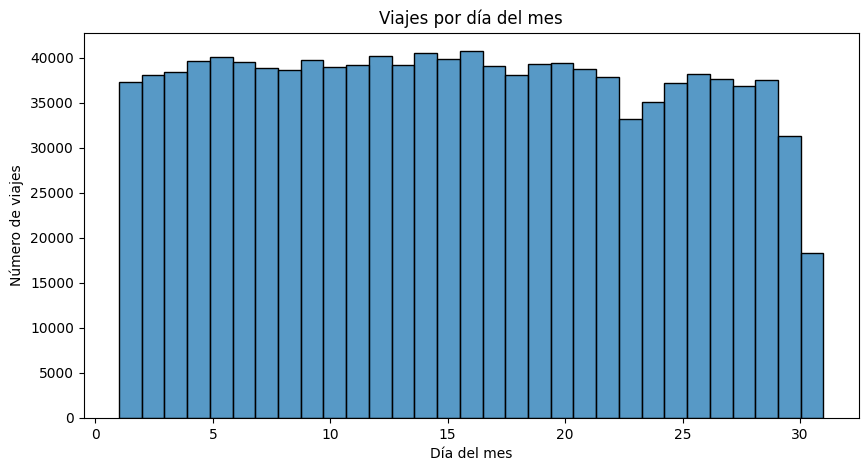

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


#Grafico 1:Viajes por día del mes.
plt.figure(figsize=(10, 5))
sns.histplot(train_df['dia_recogida'], bins=31, kde=False)
plt.xlabel('Día del mes')
plt.ylabel('Número de viajes')
plt.title('Viajes por día del mes')
plt.show()


El gráfico muestra una distribución relativamente uniforme de viajes por día del mes, con pequeñas fluctuaciones. Se observa una caída en los últimos días, especialmente el 31, posiblemente debido a meses sin ese día en la muestra. La mayoría de los días mantienen un número estable de viajes, aunque podrían existir efectos estacionales si el dataset abarca varios meses.

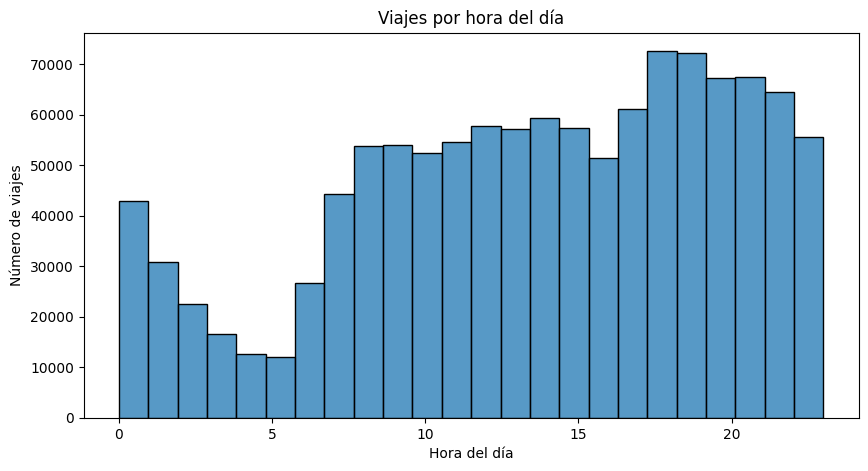

In [49]:
#Grafico 2:Viajes por hora del dia.
plt.figure(figsize=(10, 5))
sns.histplot(train_df['hora_recogida'], bins=24, kde=False)
plt.xlabel('Hora del día')
plt.ylabel('Número de viajes')
plt.title('Viajes por hora del día')
plt.show()

El gráfico muestra un alto número de viajes alrededor de la medianoche, seguido de una caída en la madrugada entre las 2 y 6 a.m., cuando la actividad es mínima. A partir de las 6 a.m., los viajes aumentan progresivamente, probablemente debido a desplazamientos matutinos. Se observa un segundo pico entre las 17 y 21 horas, lo que indica un incremento en la movilidad al final del día, posiblemente relacionado con la salida del trabajo y actividades recreativas.









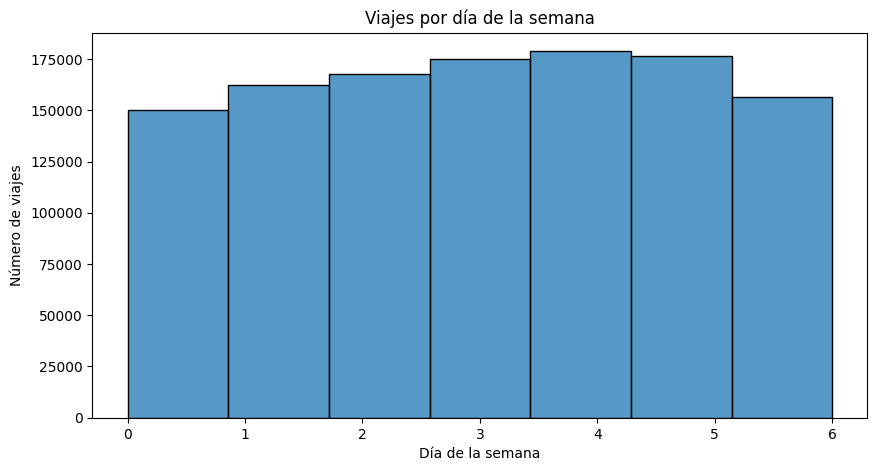

In [50]:
#Grafico 3:Viajes por día de la semana.

plt.figure(figsize=(10, 5))
sns.histplot(train_df['dia_semana_recogida'], bins=7, kde=False)
plt.xlabel('Día de la semana')
plt.ylabel('Número de viajes')
plt.title('Viajes por día de la semana')
plt.show()


El gráfico muestra que la cantidad de viajes varía a lo largo de la semana. Se observa un incremento progresivo desde el inicio de la semana, alcanzando su punto máximo entre el miércoles y el viernes. Durante el sábado y el domingo, la cantidad de viajes disminuye, lo que puede indicar una menor demanda de transporte en comparación con los días laborales.









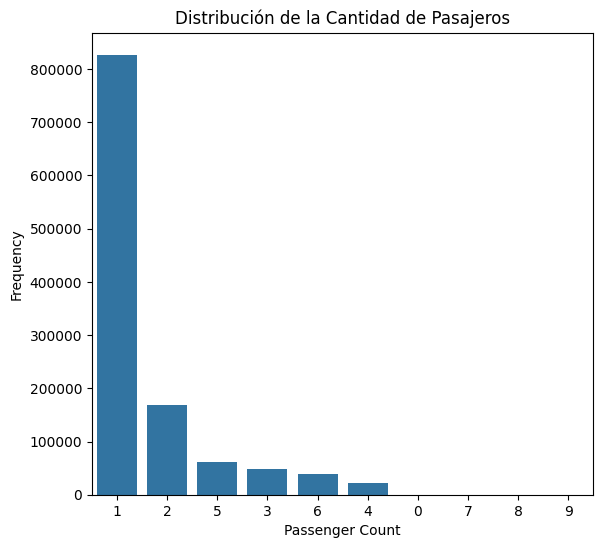

In [51]:
plt.figure(figsize=(22, 6))

# Passenger Count
plt.subplot(131)
sns.countplot(x=train_df['passenger_count'], order=train_df['passenger_count'].value_counts().index)
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.title('Distribución de la Cantidad de Pasajeros')
plt.show()


La mayoría de los viajes tienen un solo pasajero, lo que sugiere un uso predominante de taxis para transporte individual.

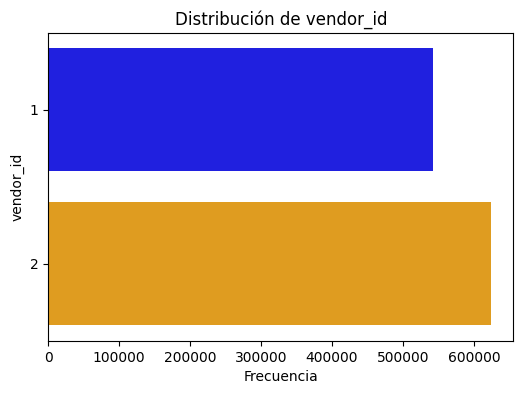

In [53]:
train_df['vendor_id'] = train_df['vendor_id'].astype(int)  # Asegurar que es entero

plt.figure(figsize=(6, 4))
sns.countplot(y=train_df['vendor_id'], hue=train_df['vendor_id'], palette={1: "blue", 2: "orange"}, legend=False)
plt.xlabel('Frecuencia')
plt.ylabel('vendor_id')
plt.title('Distribución de vendor_id')
plt.show()



Se observa que hay dos proveedores de servicio (1 y 2), con una diferencia notable en la cantidad de viajes. El proveedor 2 tiene más registros que el proveedor 1, lo que sugiere que tiene una mayor participación en los datos analizados. Esta diferencia podría influir en el análisis, por lo que sería útil investigar si existen variaciones en la calidad o el comportamiento de los viajes según el proveedor.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(6, 4))
sns.countplot(x=train_df['store_and_fwd_flag'], palette={"0": "blue", "1": "orange"})
plt.xlabel('store_and_fwd_flag')
plt.ylabel('Frecuencia')
plt.title('Distribución de store_and_fwd_flag')
plt.show()


NameError: name 'plt' is not defined

La gran mayoría de los viajes tienen un valor de 0 (o "N"), lo que significa que fueron transmitidos en tiempo real sin necesidad de almacenamiento previo.

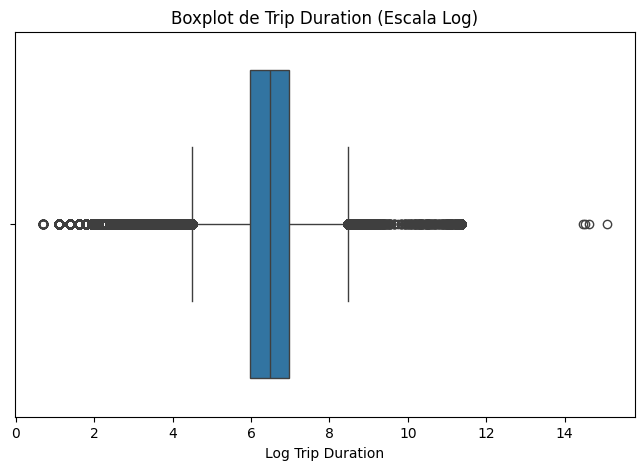

In [60]:
#Analisis de nuestra variable respuesta

plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log1p(df['trip_duration']))
plt.xlabel('Log Trip Duration')
plt.title('Boxplot de Trip Duration (Escala Log)')
plt.show()

Se observan valores atípicos a ambos lados, lo que indica la presencia de viajes inusualmente cortos o largos. La mayor concentración de datos en el centro sugiere que la mayoría de las duraciones están dentro de un rango específico, lo que facilita su análisis.

In [62]:
#Getting the summary of the trip_duration dataset
df['trip_duration'].describe()/3600 # Trip duration in hours

,trip_duration
count,405.178889
mean,0.266526
std,1.454842
min,0.000278
25%,0.110278
50%,0.183889
75%,0.298611
max,979.522778


La mayoría de los viajes duran menos de 20 minutos, con una mediana de 11 minutos. Sin embargo, hay valores atípicos extremos, como un viaje de más de 40 días, lo que genera una alta variabilidad en los datos. La desviación estándar es grande, indicando que las duraciones varían bastante.

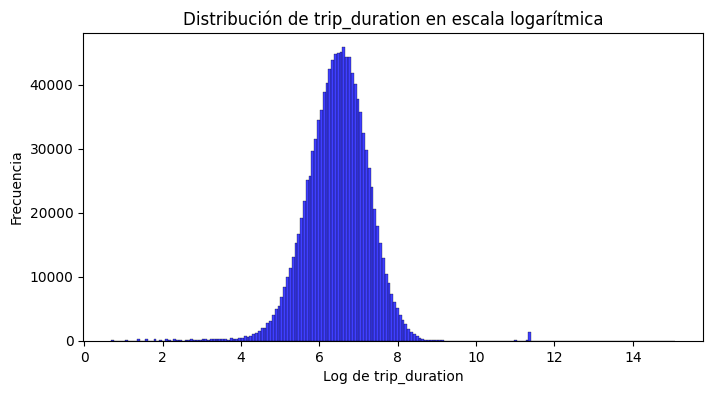

In [63]:
# Aplicar la transformación logarítmica
train_df['log_trip_duration'] = np.log(train_df['trip_duration'].values + 1)

# Graficar el histograma
plt.figure(figsize=(8, 4))
sns.histplot(train_df['log_trip_duration'], bins=200, kde=False, color="blue")

# Etiquetas y título
plt.xlabel('Log de trip_duration')
plt.ylabel('Frecuencia')
plt.title('Distribución de trip_duration en escala logarítmica')

# Mostrar el gráfico
plt.show()

In [64]:
print(train_df[['trip_duration', 'log_trip_duration']].describe())


       trip_duration  log_trip_duration
count   1.166915e+06       1.166915e+06
mean    9.592736e+02       6.466707e+00
std     5.624981e+03       7.955469e-01
min     1.000000e+00       6.931472e-01
25%     3.970000e+02       5.986452e+00
50%     6.620000e+02       6.496775e+00
75%     1.075000e+03       6.981006e+00
max     3.526282e+06       1.507575e+01


La transformación logarítmica ha ayudado a reducir la dispersión de los datos y minimizar el impacto de valores atípicos extremadamente altos. Ahora, los datos de trip_duration tienen una distribución más simétrica y normalizada, lo cual es útil para modelos de Machine Learning, especialmente aquellos que suponen normalidad en los datos.

ANALISIS BIVARIADO

In [65]:
train_df.shape

(1166915, 19)

In [68]:
train_df.columns


Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'check_trip_duration', 'dia_recogida', 'hora_recogida',
       'dia_semana_recogida', 'dia_llegada', 'hora_llegada',
       'dia_semana_llegada', 'log_trip_duration'],
      dtype='object')

In [71]:
train_df_info=train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166915 entries, 0 to 1166914
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1166915 non-null  object        
 1   vendor_id            1166915 non-null  int64         
 2   pickup_datetime      1166915 non-null  datetime64[ns]
 3   dropoff_datetime     1166915 non-null  datetime64[ns]
 4   passenger_count      1166915 non-null  int64         
 5   pickup_longitude     1166915 non-null  float64       
 6   pickup_latitude      1166915 non-null  float64       
 7   dropoff_longitude    1166915 non-null  float64       
 8   dropoff_latitude     1166915 non-null  float64       
 9   store_and_fwd_flag   1166915 non-null  category      
 10  trip_duration        1166915 non-null  int64         
 11  check_trip_duration  1166915 non-null  float64       
 12  dia_recogida         1166915 non-null  int32         
 1

In [76]:
df1 = train_df.drop(columns=['id', 'pickup_datetime', 'dropoff_datetime', 'pickup_longitude','pickup_latitude',
                       'dropoff_longitude','dropoff_latitude','trip_duration'])



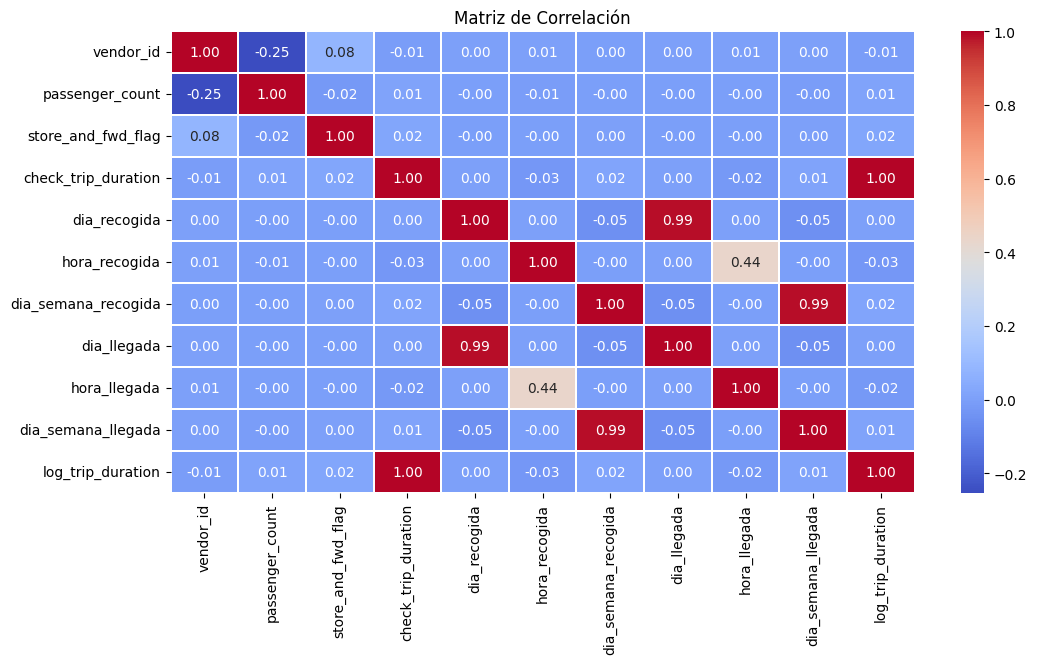

In [77]:
# Verificando la correlación entre todas las características
plt.figure(figsize=(12, 6))

# Calculando la matriz de correlación con factorize para variables categóricas
corr = df1.apply(lambda x: pd.factorize(x)[0]).corr()

# Creando el heatmap con valores numéricos dentro
ax = sns.heatmap(corr,
                 xticklabels=corr.columns,
                 yticklabels=corr.columns,
                 linewidths=.2,
                 cmap="coolwarm",  # Cambia la paleta de colores
                 annot=True,  # Agrega los valores dentro de los cuadros
                 fmt=".2f")  # Formato de los números (2 decimales)

plt.title("Matriz de Correlación")  # Título del gráfico
plt.show()


La matriz de correlación muestra las relaciones entre las variables del dataset, indicando qué tan fuertemente están asociadas entre sí. Se observa una alta correlación entre las variables relacionadas con el tiempo, como el día de recogida y día de llegada (0.99) y el día de la semana de recogida y llegada (0.99), lo cual es esperado, ya que la mayoría de los viajes ocurren dentro del mismo día. La hora de recogida y hora de llegada tienen una correlación moderada (0.44), lo que sugiere que la hora de inicio influye parcialmente en la hora de finalización, pero no de manera estrictamente lineal.

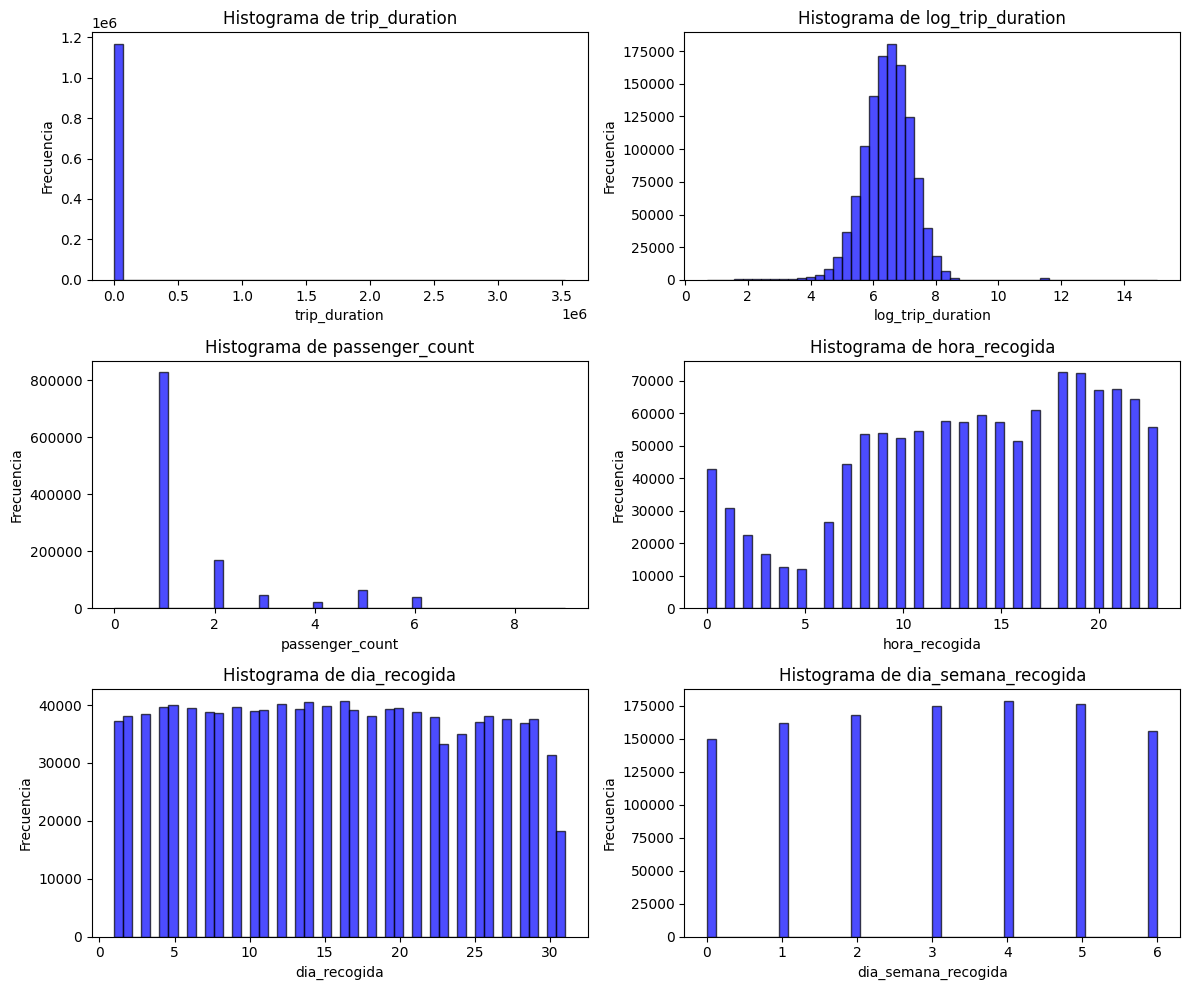

In [79]:
# Lista de características que parecen ser relevantes según la matriz de correlación
features = ['trip_duration', 'log_trip_duration', 'passenger_count',
            'hora_recogida', 'dia_recogida', 'dia_semana_recogida']

plt.figure(figsize=(12, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    plt.hist(train_df[feature], bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.title(f'Histograma de {feature}')

plt.tight_layout()
plt.show()

El análisis de los histogramas revela que la variable log_trip_duration, que es la versión transformada de la duración del viaje, sigue aproximadamente una distribución normal, lo cual es beneficioso para modelos estadísticos que asumen normalidad en la variable objetivo.

Latitud y longitud

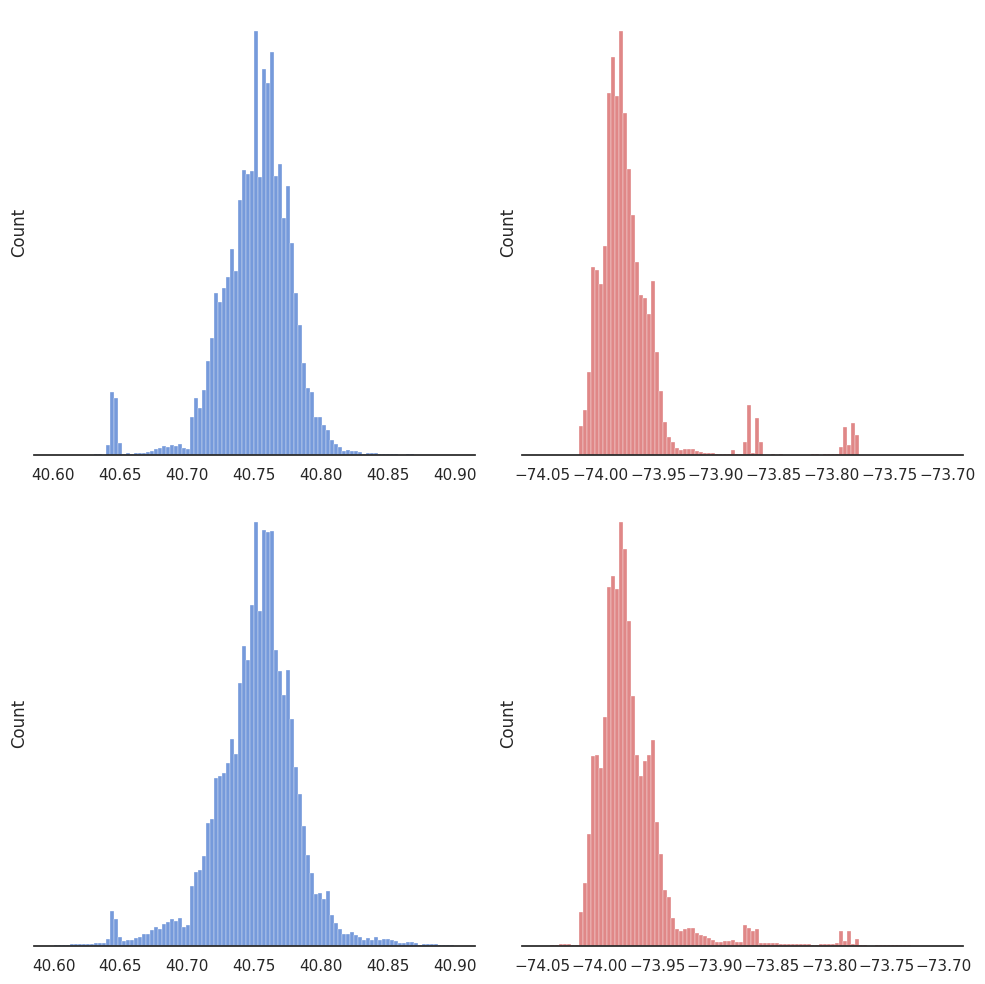

In [80]:
# Filtrar solo viajes dentro de Nueva York
train_df = train_df.loc[(train_df.pickup_latitude > 40.6) & (train_df.pickup_latitude < 40.9)]
train_df = train_df.loc[(train_df.dropoff_latitude > 40.6) & (train_df.dropoff_latitude < 40.9)]
train_df = train_df.loc[(train_df.dropoff_longitude > -74.05) & (train_df.dropoff_longitude < -73.7)]
train_df = train_df.loc[(train_df.pickup_longitude > -74.05) & (train_df.pickup_longitude < -73.7)]

# Crear una copia del DataFrame filtrado
train_df_filtered = train_df.copy()

# Configuración de estilo para los gráficos
sns.set(style="white", palette="muted", color_codes=True)

# Crear subgráficos (2x2)
f, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False, sharey=False)
sns.despine(left=True)

# Histogramas de coordenadas
sns.histplot(train_df_filtered['pickup_latitude'].values, label='pickup_latitude', color="b", bins=100, ax=axes[0, 0])
sns.histplot(train_df_filtered['pickup_longitude'].values, label='pickup_longitude', color="r", bins=100, ax=axes[0, 1])
sns.histplot(train_df_filtered['dropoff_latitude'].values, label='dropoff_latitude', color="b", bins=100, ax=axes[1, 0])
sns.histplot(train_df_filtered['dropoff_longitude'].values, label='dropoff_longitude', color="r", bins=100, ax=axes[1, 1])

# Ajustes finales
plt.setp(axes, yticks=[])
plt.tight_layout()
plt.show()

Se observan picos alrededor de 40.75° de latitud y -73.95° de longitud, lo que sugiere que la mayoría de los viajes inician y terminan en ubicaciones centrales de Nueva York, posiblemente en Manhattan.